In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

Path('plots').mkdir(exist_ok=True)

zs = pd.read_csv('data/LLM_Response_Log - Zero-Shot.csv', encoding='utf-8-sig')
ft = pd.read_csv('data/fine_tuned_scores.csv', encoding='utf-8-sig')
fs = pd.read_csv('data/few_shot_scores.csv', encoding='utf-8-sig')

zs.columns = [c.strip() for c in zs.columns]
ft.columns = [c.strip() for c in ft.columns]
fs.columns = [c.strip() for c in fs.columns]

zs['Accuracy Score']   = pd.to_numeric(zs['Accuracy Score'],   errors='coerce')
zs['Sentiment Score']  = pd.to_numeric(zs['Sentiment Score'],  errors='coerce')
zs['Response Length']  = pd.to_numeric(zs['Response Length'],  errors='coerce')
ft['Accuracy Score']   = pd.to_numeric(ft['Accuracy Score'],   errors='coerce')
ft['Sentiment Score']  = pd.to_numeric(ft['Sentiment Score'],  errors='coerce')
ft['Response Length']  = pd.to_numeric(ft['Response Length'],  errors='coerce')
fs['Sentiment Score']  = pd.to_numeric(fs['Sentiment Score'],  errors='coerce')
fs['Response Length']  = pd.to_numeric(fs['Response Length'],  errors='coerce')

CATEGORIES = ['Factual QA', 'Reasoning', 'Explanation']
MODELS     = ['Gemini 3 Pro', 'Microsoft Copilot Pro', 'LLaMA 3.2 3B']
METRICS    = ['Accuracy Score', 'Sentiment Score', 'Response Length']
YLABELS    = ['Accuracy (0-1)', 'Sentiment (1-5)', 'Response Length (words)']

# color assignments — kept consistent and non-overlapping across all plots
BLUE   = '#4C72B0'  # English
RED    = '#C44E52'  # Spanish
GREEN  = '#55A868'  # Zero-Shot
PURPLE = '#8172B2'  # Fine-Tuned
ORANGE = '#DD8452'  # Gemini
TEAL   = '#64B5CD'  # Copilot
GOLD   = '#CCB974'  # LLaMA

print('Zero-Shot rows:', len(zs))
print('Fine-Tuned rows:', len(ft))
print('Few-Shot rows:', len(fs))

Zero-Shot rows: 378
Fine-Tuned rows: 42
Few-Shot rows: 126


## Plot 1: Zero-Shot vs Fine-Tuned LLaMA 3.2 3B by Category

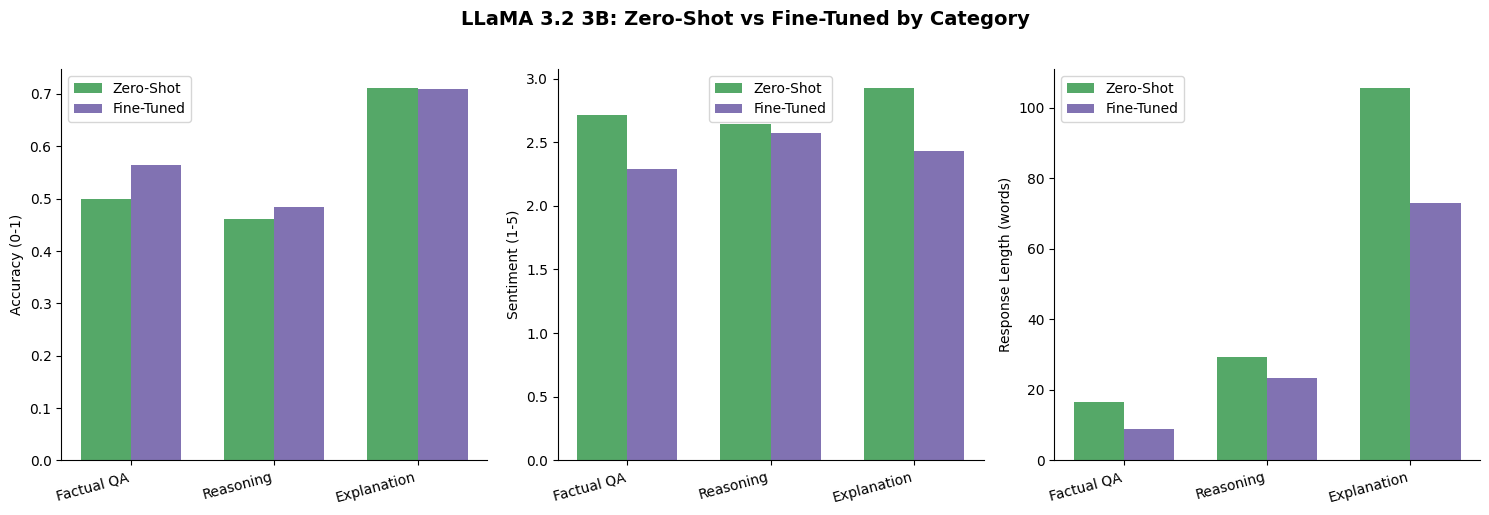

In [19]:
fine_tuned_prompts = set(ft['Prompt'].str.strip())
llama_zs = zs[(zs['Model'].str.strip() == 'LLaMA 3.2 3B') &
               (zs['Prompt'].str.strip().isin(fine_tuned_prompts))].copy()

zs_means = llama_zs.groupby('Category')[METRICS].mean()
ft_means = ft.groupby('Category')[METRICS].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('LLaMA 3.2 3B: Zero-Shot vs Fine-Tuned by Category', fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(CATEGORIES))
width = 0.35

for ax, metric, ylabel in zip(axes, METRICS, YLABELS):
    ax.bar(x - width/2, [zs_means.loc[c, metric] for c in CATEGORIES], width, label='Zero-Shot', color=GREEN)
    ax.bar(x + width/2, [ft_means.loc[c, metric] for c in CATEGORIES], width, label='Fine-Tuned', color=PURPLE)
    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORIES, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/plot1_zeroshot_vs_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2: English vs Spanish by Model (Zero-Shot)

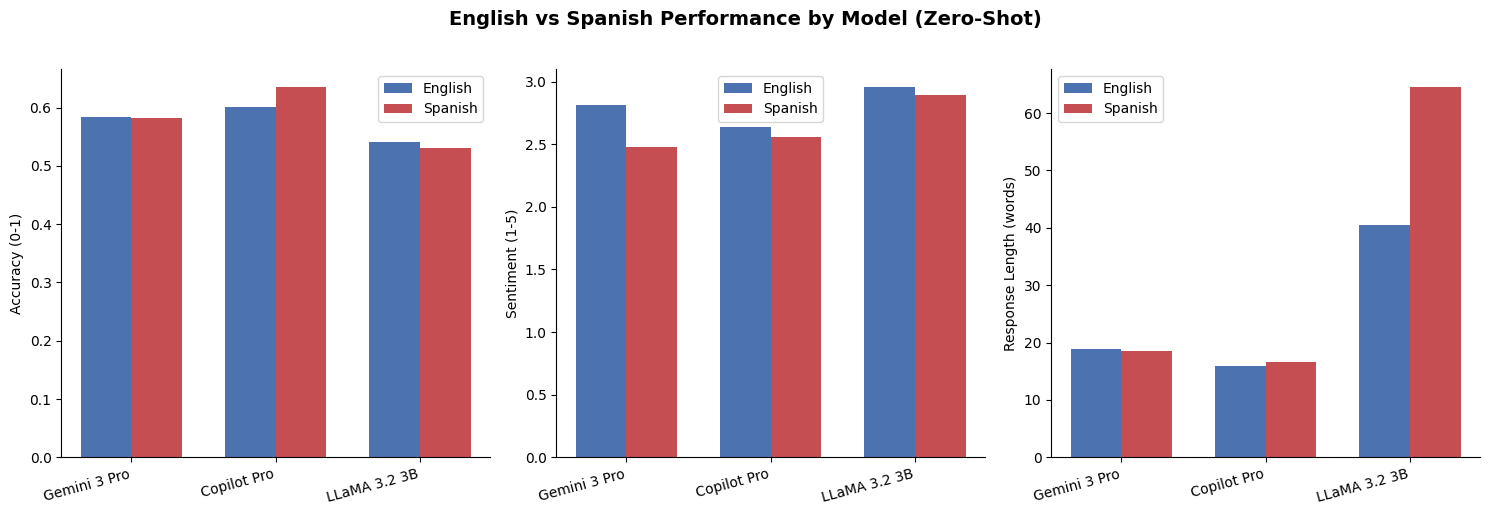

In [20]:
lang_means = zs.groupby(['Model', 'Language'])[METRICS].mean().reset_index()
model_labels = ['Gemini 3 Pro', 'Copilot Pro', 'LLaMA 3.2 3B']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('English vs Spanish Performance by Model (Zero-Shot)', fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(MODELS))
width = 0.35

for ax, metric, ylabel in zip(axes, METRICS, YLABELS):
    for i, (lang, color) in enumerate([('English', BLUE), ('Spanish', RED)]):
        vals = [lang_means[(lang_means['Model'] == m) & (lang_means['Language'] == lang)][metric].values[0]
                for m in MODELS]
        ax.bar(x + (i - 0.5) * width, vals, width, label=lang, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/plot2_english_vs_spanish.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3: Performance by Category across Models (Zero-Shot)

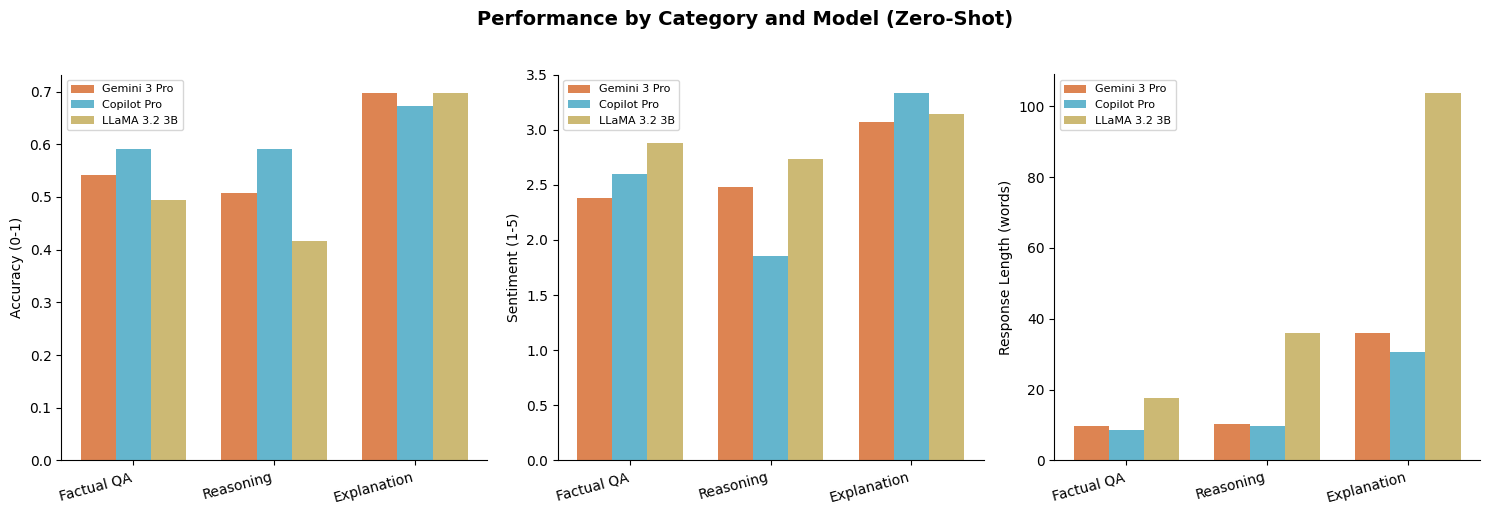

In [21]:
cat_means = zs.groupby(['Category', 'Model'])[METRICS].mean().reset_index()
model_colors = [ORANGE, TEAL, GOLD]
model_labels  = ['Gemini 3 Pro', 'Copilot Pro', 'LLaMA 3.2 3B']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Performance by Category and Model (Zero-Shot)', fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(CATEGORIES))
width = 0.25

for ax, metric, ylabel in zip(axes, METRICS, YLABELS):
    for i, (model, color, label) in enumerate(zip(MODELS, model_colors, model_labels)):
        vals = [cat_means[(cat_means['Category'] == c) & (cat_means['Model'] == model)][metric].values[0]
                for c in CATEGORIES]
        ax.bar(x + (i - 1) * width, vals, width, label=label, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORIES, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/plot3_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4: Performance by Category across Models (Few-Shot)

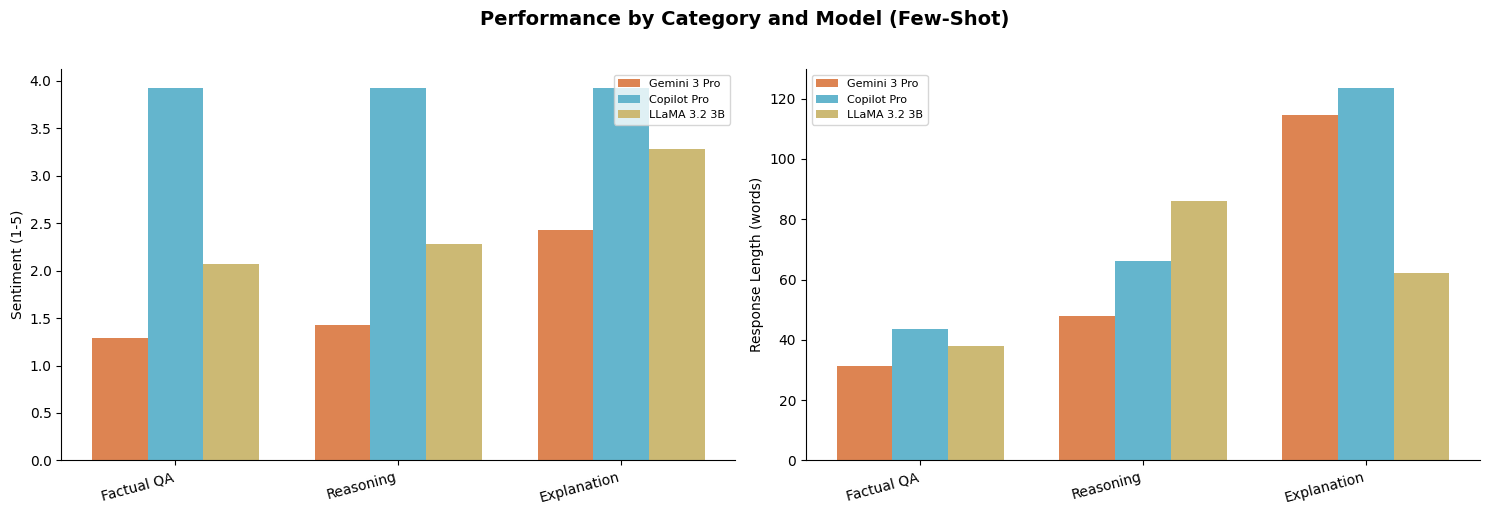

In [22]:
metrics = ['Sentiment Score', 'Response Length']
cat_means = fs.groupby(['Category', 'Model'])[METRICS[1:]].mean().reset_index()
model_colors = [ORANGE, TEAL, GOLD]
model_labels  = ['Gemini 3 Pro', 'Copilot Pro', 'LLaMA 3.2 3B']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Performance by Category and Model (Few-Shot)', fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(CATEGORIES))
width = 0.25

for ax, metric, ylabel in zip(axes, METRICS[1:], YLABELS[1:]):
    for i, (model, color, label) in enumerate(zip(MODELS, model_colors, model_labels)):
        vals = [cat_means[(cat_means['Category'] == c) & (cat_means['Model'] == model)][metric].values[0]
                for c in CATEGORIES]
        ax.bar(x + (i - 1) * width, vals, width, label=label, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORIES, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/plot4_by_category_few_shot.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 5: Few-Shot English vs Spanish by Model

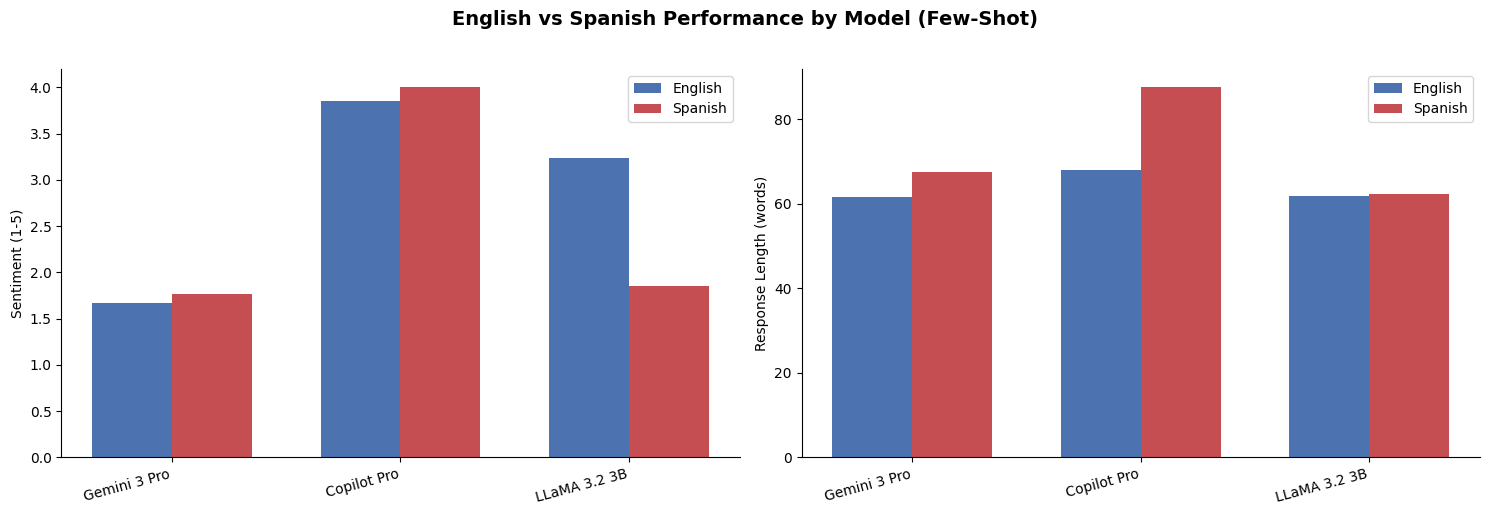

In [23]:
fs_lang = fs.groupby(['Model', 'Language'])[['Sentiment Score', 'Response Length']].mean().reset_index()
model_labels = ['Gemini 3 Pro', 'Copilot Pro', 'LLaMA 3.2 3B']
fs_metrics  = ['Sentiment Score', 'Response Length']
fs_ylabels  = ['Sentiment (1-5)', 'Response Length (words)']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('English vs Spanish Performance by Model (Few-Shot)', fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(MODELS))
width = 0.35

for ax, metric, ylabel in zip(axes, fs_metrics, fs_ylabels):
    for i, (lang, color) in enumerate([('English', BLUE), ('Spanish', RED)]):
        vals = [fs_lang[(fs_lang['Model'] == m) & (fs_lang['Language'] == lang)][metric].values[0]
                for m in MODELS]
        ax.bar(x + (i - 0.5) * width, vals, width, label=lang, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/plot5_fewshot_english_vs_spanish.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 6: LLaMA Zero-Shot vs Fine-Tuned by Language

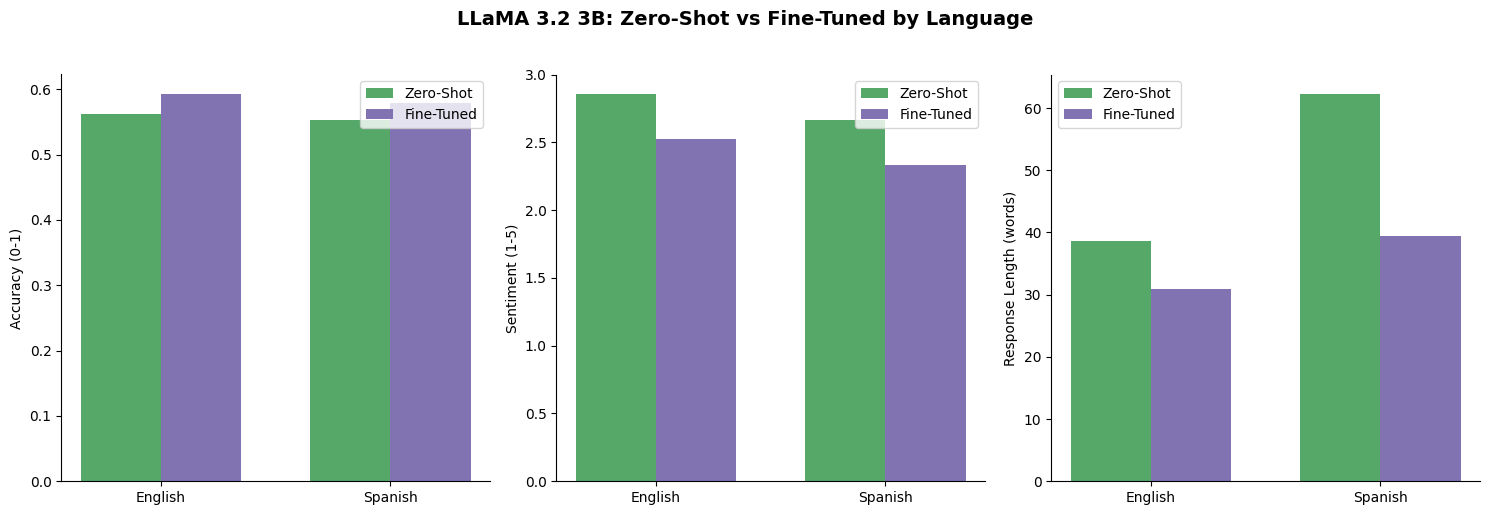

In [24]:
# compare LLaMA zero-shot vs fine-tuned broken down by language
fine_tuned_prompts = set(ft['Prompt'].str.strip())
llama_zs_sub = zs[(zs['Model'].str.strip() == 'LLaMA 3.2 3B') &
                   (zs['Prompt'].str.strip().isin(fine_tuned_prompts))].copy()

p6_metrics = ['Accuracy Score', 'Sentiment Score', 'Response Length']
p6_ylabels = ['Accuracy (0-1)', 'Sentiment (1-5)', 'Response Length (words)']

zs_lang = llama_zs_sub.groupby('Language')[p6_metrics].mean()
ft_lang  = ft.groupby('Language')[p6_metrics].mean()

langs = ['English', 'Spanish']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('LLaMA 3.2 3B: Zero-Shot vs Fine-Tuned by Language', fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(langs))
width = 0.35

for ax, metric, ylabel in zip(axes, p6_metrics, p6_ylabels):
    ax.bar(x - width/2, [zs_lang.loc[l, metric] for l in langs], width, label='Zero-Shot', color=GREEN)
    ax.bar(x + width/2, [ft_lang.loc[l, metric]  for l in langs], width, label='Fine-Tuned', color=PURPLE)
    ax.set_xticks(x)
    ax.set_xticklabels(langs)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/plot6_llama_language_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()